In [122]:
import xarray as xr
import rioxarray 
import matplotlib.pyplot as plt
import numpy as np

from pyproj import Transformer
from scipy.interpolate import griddata


import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [123]:
target = xr.open_dataset("/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/Model data - grid info/BCC-CSM-MR/proj_ssp126/tas_Amon_BCC-CSM2-MR_ssp126_r1i1p1f1_gn_201501-210012.nc")

source = xr.open_dataset("/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/MSc/ERA5/ERA5 - pressure levels/020304_dec_press_lev_500_hPa.nc")

In [124]:
source

<xarray.Dataset> Size: 40MB
Dimensions:         (valid_time: 72, pressure_level: 1, latitude: 132,
                     longitude: 355)
Coordinates:
    number          int64 8B ...
  * valid_time      (valid_time) datetime64[ns] 576B 1999-12-02 ... 1999-12-0...
  * pressure_level  (pressure_level) float64 8B 500.0
  * latitude        (latitude) float64 1kB 70.25 70.0 69.75 ... 38.0 37.75 37.5
  * longitude       (longitude) float64 3kB -55.75 -55.5 -55.25 ... 32.5 32.75
    expver          (valid_time) <U4 1kB ...
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 13MB ...
    pv              (valid_time, pressure_level, latitude, longitude) float32 13MB ...
    vo              (valid_time, pressure_level, latitude, longitude) float32 13MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-09T11:48 GRIB to CDM+CF via cfgrib-0.9.1...

In [125]:
target_recalibrated = target.assign_coords(lon=(target['lon'] - 180.0))

target_slice = target_recalibrated.sel(
	lon=slice(source['longitude'].min().item(), source['longitude'].max().item()),
	lat=slice(source['latitude'].min().item(), source['latitude'].max().item())
)

In [153]:
lon_source, lat_source = np.meshgrid(source.longitude, source.latitude)
lon_target, lat_target = np.meshgrid(target_slice.lon, target_slice.lat)

In [154]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:4326", always_xy=True)

In [158]:
x_source, y_source = transformer.transform(lon_source, lat_source)
x_target, y_target = transformer.transform(lon_target, lat_target)

shape_target = x_target.shape

(132, 355)

In [160]:
new_data = griddata(
    list(zip(x_source.ravel(), y_source.ravel())),
source['z'].isel(valid_time=42).values.ravel(),
    list(zip(x_target.ravel(), y_target.ravel())),
    method='linear'
)
new_data = new_data.reshape(shape_target)

In [175]:
z_source = source['z'].isel(valid_time=42).squeeze()
print(z_source.dims, z_source.shape)

('latitude', 'longitude') (132, 355)


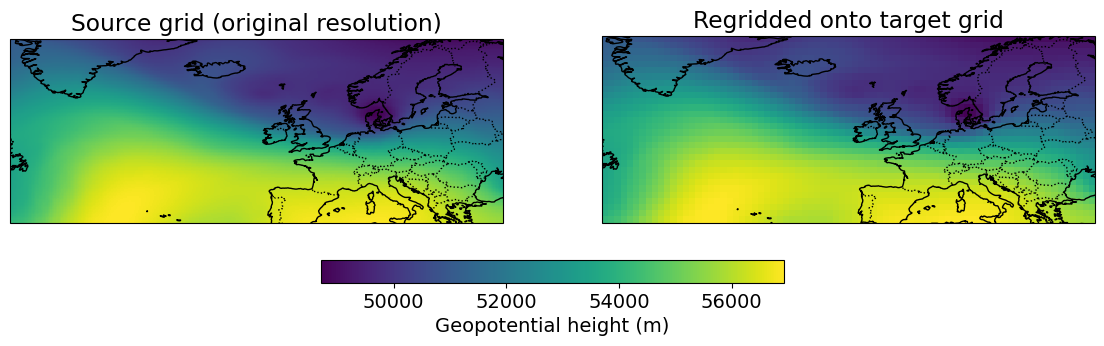

In [177]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Shared color scale so the two panels are comparable
vmin = min(source['z'].isel(valid_time=42).values.min(), np.nanmin(new_data))
vmax = max(source['z'].isel(valid_time=42).values.max(), np.nanmax(new_data))

fig, axes = plt.subplots(
    1, 2, figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# --- Left: source data on its original grid ---
ax = axes[0]
im0 = ax.pcolormesh(
    source['longitude'], source['latitude'],
    z_source,
    transform=ccrs.PlateCarree(),
    vmin=vmin, vmax=vmax, cmap='viridis', shading='auto'
)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Source grid (original resolution)')

# --- Right: regridded data on target grid ---
ax = axes[1]
im1 = ax.pcolormesh(
    target_slice.lon, target_slice.lat,
    new_data,
    transform=ccrs.PlateCarree(),
    vmin=vmin, vmax=vmax, cmap='viridis', shading='auto'
)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Regridded onto target grid')

fig.colorbar(im1, ax=axes, orientation='horizontal', fraction=0.05, pad=0.08, label='Geopotential height (m)')
plt.show()

# Next step: Using moaap to track on the regridded data. 

## 1: save data as .nc file

